In [ ]:
from huggingface_hub import hf_hub_download
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from aeon.classification.interval_based import RSTSF
from sklearn.metrics import accuracy_score
from autotsc.models import LokyStackerV7
from autotsc.old_models import StackerV4, LokyStackerV5, LokyStackerV5SoftRF, LokyStackerV6
from autotsc import utils
from aeon.classification.convolution_based import MultiRocketHydraClassifier
import matplotlib.pyplot as plt  
from autotsc.data_loader import load_fold_monash
import polars as pl
from autotsc.data_loader import load_fold_monash_subset
import matplotlib.pyplot as plt
from autotsc.data_loader import load_fold

In [2]:
#X_train, y_train, X_test, y_test = load_fold_monash("Pedestrian", fold=0)
#print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

In [3]:
#X_train, y_train, X_test, y_test = load_fold_monash_subset("Pedestrian", fold=0, subset_fraction_to_keep=0.05)
#print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

In [4]:
X_train, y_train, X_test, y_test = load_fold("Crop", 0)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(7200, 1, 46) (7200,) (16800, 1, 46) (16800,)


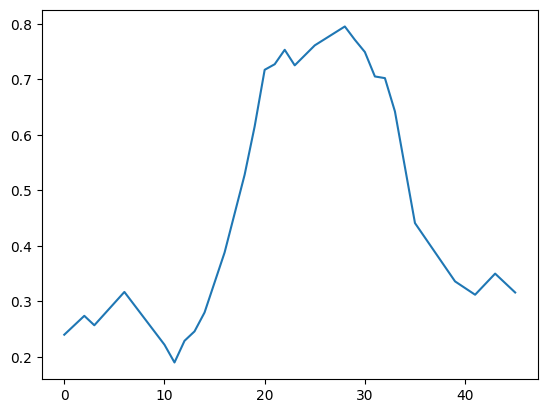

In [5]:
plt.plot(X_train[0, 0, :])

In [6]:
ssG=ergerg

NameError: name 'ergerg' is not defined

In [ ]:
def load_monash_fold(dataset_name: str, fold: int, test_size: float = 0.2):
    path_X = hf_hub_download(
        repo_id=f"monster-monash/{dataset_name}",
        filename=f"{dataset_name}_X.npy",
        repo_type="dataset",
    )
    path_y = hf_hub_download(
        repo_id=f"monster-monash/{dataset_name}",
        filename=f"{dataset_name}_y.npy",
        repo_type="dataset",
    )
    X = np.load(path_X, mmap_mode="r")
    y = np.load(path_y, mmap_mode="r")

    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=fold)
    train_idx, test_idx = next(sss.split(X, y))

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

X_train, y_train, X_test, y_test = load_monash_fold("LakeIce", 10)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)
print(X_train.dtype)
print(y_train.dtype)

In [ ]:
dataset_name = "Pedestrian"
path_y = hf_hub_download(
    repo_id=f"monster-monash/{dataset_name}",
    filename=f"{dataset_name}_y.npy",
    repo_type="dataset",
)

In [ ]:
fold = hf_hub_download(
    repo_id=f"monster-monash/{dataset_name}",
    filename=f"test_indices_fold_0.txt",
    repo_type="dataset",
)
# np.load(fold, mmap_mode="r").shape

In [ ]:
import polars as pl
pl.scan_lines(fold).with_columns(pl.col('lines').cast(pl.Int32).alias('lines')).collect()['lines'].to_numpy()

In [ ]:
#from datasets import load_dataset
#
#dataset = load_dataset("monster-monash/Pedestrian", "fold_0", trust_remote_code = True)

In [ ]:
dataset

In [ ]:
train = dataset["train"]

X_train = train["series"]
y_train = train["target"]

test = dataset["test"]
X_test = test["series"]
y_test = test["target"]
#print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

In [ ]:
train = dataset["train"]

X_train = train["X"]
y_train = train["y"]

test = dataset["test"]
X_test = test["X"]
y_test = test["y"]

In [ ]:
import pyarrow
pyarrow.__version__